In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from shapely.geometry import Point

from pyproj import Transformer 

import pandas as pd
import numpy as np
import pickle

In [29]:
# configure the place, network type, trip times, and travel speed
#place = {"city": "Berkeley", "state": "California"}
#place = "Vienna, Austria"
#place = "Vorarlberg, Austria"
target_crs = "epsg:31287"

places = [{"city": "Vienna", "country": "Austria"},
          {"state": "Lower Austria", "country": "Austria"},
          {"state": "Upper Austria", "country": "Austria"},
          {"state": "Burgenland", "country": "Austria"},
          {"state": "Salzburg", "country": "Austria"},
          {"state": "Styria", "country": "Austria"},
          {"state": "Carinthia", "country": "Austria"},
          {"state": "Tyrol", "country": "Austria"},
          {"state": "Vorarlberg", "country": "Austria"}]

network_type = "walk"
simplify = True

# TODO: change place/region to desired values
#place = {"city": "Vienna", "country": "Austria"}
place = {"state": "Tyrol", "country": "Austria"}
region = "all_regions_20240528.csv"
#region = "vmobil_obb_20240528.csv"

distances = [300, 500, 750, 1000, 1250]
ptsql_colors = ["#E42421", "#E95153", "#E63C1E", "#F29668", "#34672B", "#87C281", "#959595", "none"]

path_graphs_out = "../data/in/osmnx_graphs/"
path_stops_in = "../data/out/stop_dfs/"

In [30]:
ptsql_color_table = [[0,0,1,2,3], # I
                    [0,1,2,3,4], # II
                    [1,2,3,4,5], # III
                    [2,3,4,5,6], # IV
                    [3,4,5,6,6], # V
                    [4,5,6,-1,-1], # VI
                    [5,6,6,-1,-1], # VII
                    [6,6,-1,-1,-1]] # VIII

def assign_color(category, distance):
    """
    Lookup the ptsql based on the station category and the distance level.
    """
    if distance <= 300:
        return ptsql_color_table[category][0]
    elif distance <= 500:
        return ptsql_color_table[category][1]
    elif distance <= 750:
        return ptsql_color_table[category][2]
    elif distance <= 1000:
        return ptsql_color_table[category][3]
    elif distance <= 1250:
        return ptsql_color_table[category][4]
    else:
        return -1

In [31]:
def draw_graph(G, ns=0, nc="none", gdf=None, return_fig=False):
    fig, ax = ox.plot.plot_graph(
        G,
        node_color=nc,
        node_size=ns,
        edge_color="#999999",
        edge_alpha=0.2,
        show=False,
        close=False,
        figsize=(12, 12),
        dpi=300,
    )
    if gdf is not None:
        gdf.plot(ax=ax, color=gdf.index, ec="none", alpha=1, zorder=-1)

    #plt.show()

    if return_fig:
        return fig, ax

In [32]:
def create_name(place, simplify):
    name = ""
    if isinstance(place, list):
        "_".join([p.get('state', p.get('city', "")) for p in place])
    else:
        name += place.get('state', place.get('city', ""))

    if not simplify:
        name += "_full_graph"

    return name

## Download and prep the street network

In [33]:
# download the street network
#name = place.get("state", place.get("city"))
name = create_name(place, simplify)
print(name)
#G = ox.graph.graph_from_place(place, network_type=network_type, simplify=simplify)
# TODO: maybe use "simplify=False" to get the full street network

Tyrol


In [34]:
# load or save graph from/to folder
# if place.get("county", None) == "Lienz":
#     name = "East"+name

# ox.save_graphml(G, f"{path_graphs_out}/graph_{name}.graphml")
# with open(f"{path_graphs_out}graph_{name}.pkl", "wb") as f:
#     pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

#G = ox.load_graphml(f"{path_graphs_out}/graph_{name}.graphml")

with open(f"{path_graphs_out}graph_{name}.pkl", "rb") as f:
    G = pickle.load(f)

In [35]:
# project graph to target crs (epsg:31287)
G = ox.projection.project_graph(G, to_crs=target_crs)

In [36]:
# export  as geopackage for qgis

# edges = ox.graph_to_gdfs(G, nodes=False)
# edges.to_file(f"{path_graphs_out}/graph_{name}.gpkg", driver="GPKG")

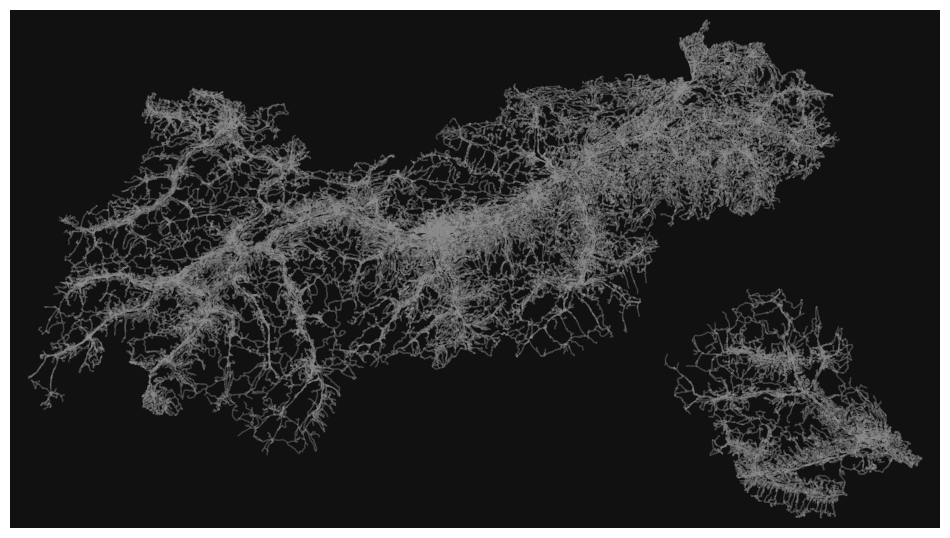

In [37]:
draw_graph(G)

In [38]:
# load stop data for region
df = pd.read_csv(f"{path_stops_in}{region}")

# project coordinates to target crs
transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
df["x"], df["y"] = transformer.transform(df["stop_lon"].values, df["stop_lat"].values)

#df.to_csv(f"{path_stops_in}all_regions_20240528_{target_crs}.csv", index=False)

df

,stop_id,stop_name,stop_lat,stop_lon,rank,count,interval,category,x,y
0,at:41:10005,Sieggraben Gemeindeamt,47.649966,16.379351,3,99,16.969697,3,628764.998391,421200.487965
1,at:41:10018,Antau Kleine Zeile,47.774498,16.475309,3,36,46.666667,5,635407.069652,435317.271767
2,at:41:10019,Stöttera Ost,47.769928,16.464412,3,37,45.405405,5,634611.747521,434776.778490
3,at:41:10020,Zemendorf Volksschule,47.765448,16.454648,3,37,45.405405,5,633900.629523,434249.811357
4,at:41:10021,Zemendorf Wr. Neustädter Str.,47.762356,16.451638,3,37,45.405405,5,633689.068862,433897.409845
...,...,...,...,...,...,...,...,...,...,...
30654,at:49:994,Wien Parlament,48.208679,16.360073,2,873,1.924399,0,624902.060761,483200.593100
30655,at:49:995,Wien Patrizigasse,48.257248,16.404144,3,347,4.841499,0,627961.116156,488724.039463
30656,at:49:997,Wien Paulinensteig,48.218406,16.299491,3,160,10.500000,3,620362.634074,484107.753608
30657,at:49:998,Wien Pellmanngasse,48.130752,16.288477,3,113,14.867257,3,619915.163235,474339.757555


## Test to find nodes closest node to given station coordinates
(needed to run later code)

In [39]:

nc = []
ns = []

# find closest node in network to each stop
nodes, dists = ox.nearest_nodes(G, df['x'], df['y'], return_dist=True)
print(len(nodes))


node_list = np.rec.fromarrays([nodes, df["stop_id"], df['category']])

print(node_list)
print(len(node_list))

# test: assign a color to each node based on the distance to its correct stop position
bins = [10, 25, 50, 1000]
colors = np.array(["green", "yellow", "orange", "red", "black"])
node_colors = colors[np.digitize(dists, bins)]

for n in G.nodes():
    if n in nodes:
        c = node_colors[np.where(nodes == n)[0][0]]
        if c != 'black':
            ns.append(15)
            nc.append(c)
        else:
            ns.append(0)
            nc.append("none")
    else:
        ns.append(0)
        nc.append("none")


30659
[(1476719592, 'at:41:10005', 3) (4777657632, 'at:41:10018', 5)
 (4777657632, 'at:41:10019', 5) ... (1569031555, 'at:49:997', 3)
 (1569031555, 'at:49:998', 3) (1569031555, 'at:49:999', 4)]
30659


In [40]:
print(np.unique(node_colors, return_counts=True))

(array(['black', 'green', 'orange', 'red', 'yellow'], dtype='<U6'), array([27517,  1485,   380,   129,  1148]))


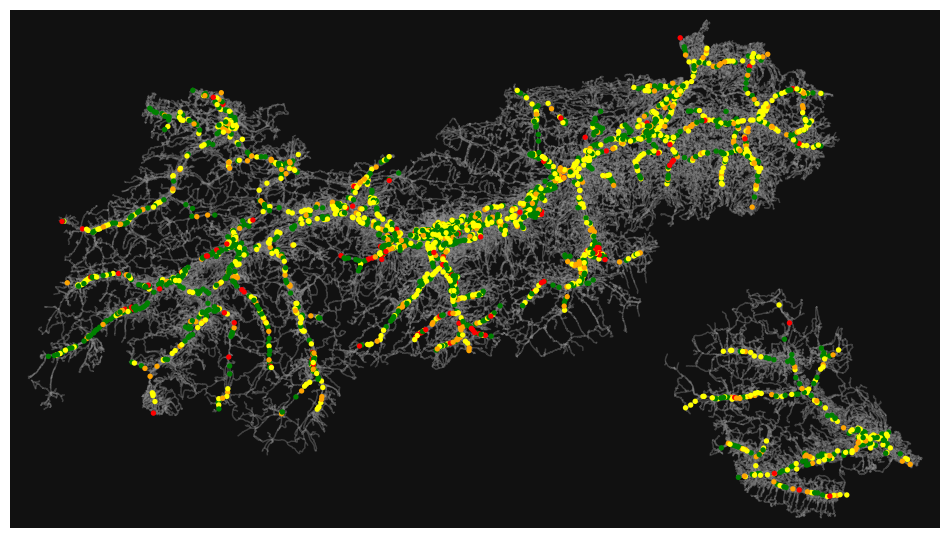

In [41]:
draw_graph(G, ns, nc)

# green: node withing 10m of actual location
# yellow: node withing 25m of actual location
# orange: node withing 50m of actual location
# red: nodes even further away
# red also contains nodes outside of bregenz.

## Plot the time-distances as isochrones

In [ ]:
# make the isochrone polygons
isochrone_polys = []
for cn,_,cat in node_list:
    for d in sorted(distances, reverse=True):
        subgraph = nx.ego_graph(G, cn, radius=d, distance="length")
        node_points = [Point((data["x"], data["y"])) for node, data in subgraph.nodes(data=True)]
        bounding_poly = gpd.GeoSeries(node_points).union_all().convex_hull.buffer(10)
        isochrone_polys.append({
            "center": cn,
            #"distance": d,
            #"category": cat,
            "color": ptsql_colors[assign_color(cat,d)],
            "geometry": bounding_poly
        })
gdf = gpd.GeoDataFrame(isochrone_polys)

                                                  geometry       center
color                                                                  
none     MULTIPOLYGON (((127696.17 405159.02, 127696.16...  10795949940
#959595  MULTIPOLYGON (((127696.165 405159.023, 127696....  11162779196
#87C281  MULTIPOLYGON (((127572.028 405256.874, 127572....  11162779196
#34672B  MULTIPOLYGON (((127696.164 405159.024, 127696....  11162779196
#F29668  MULTIPOLYGON (((127696.171 405159.019, 127696....  11162779196
#E63C1E  MULTIPOLYGON (((127696.255 405158.972, 127696....  11162779196
#E95153  MULTIPOLYGON (((127942.724 405042.16, 127942.7...  11162779196
#E42421  MULTIPOLYGON (((128900.974 404876.686, 128900....  11162779196


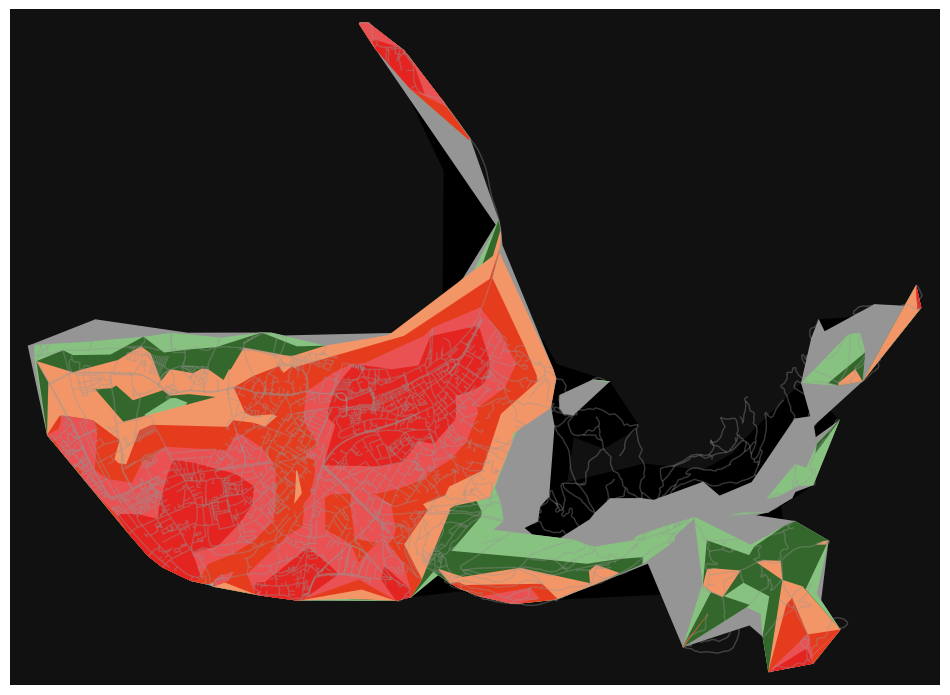

In [ ]:
# dissolve all entries with the same color into one and 
# sort by color to plot lower rank colors first and higher rank colors on top
gdf_dissolved = gdf.dissolve(by="color").reindex(ptsql_colors[::-1])

print(gdf_dissolved)

draw_graph(G, gdf=gdf_dissolved)

## Faster version without re-selecting nodes in inner distances

In [42]:
records = []

for cn,_,cat in node_list:

    # select all nodes within the max distance
    lengths = nx.single_source_dijkstra_path_length(
        G,
        cn,
        cutoff=distances[-1],
        weight="length"
    )

    prev_d = 0
    # for each distance, select all nodes in the distance band
    for d in distances:
        color = ptsql_colors[assign_color(cat, d)]
        if color == "none": #skip black areas
            break #skip entire loop for this node since there are no colored isos left

        ring_nodes = [ Point((G.nodes[n]["x"], G.nodes[n]["y"])) for n, dist in lengths.items() if prev_d < dist <= d ]

        if ring_nodes:
            poly = gpd.GeoSeries(ring_nodes).union_all().convex_hull.buffer(25)
            
            records.append({
                "center": cn,
                "distance": d,
                "color": color,
                "geometry": poly
            })

        prev_d = d

# edges = ox.graph_to_gdfs(G.subgraph(lengths.keys()), nodes=False)
# iso_poly = edges.buffer(20).unary_union


gdf = gpd.GeoDataFrame(records, crs=G.graph["crs"])

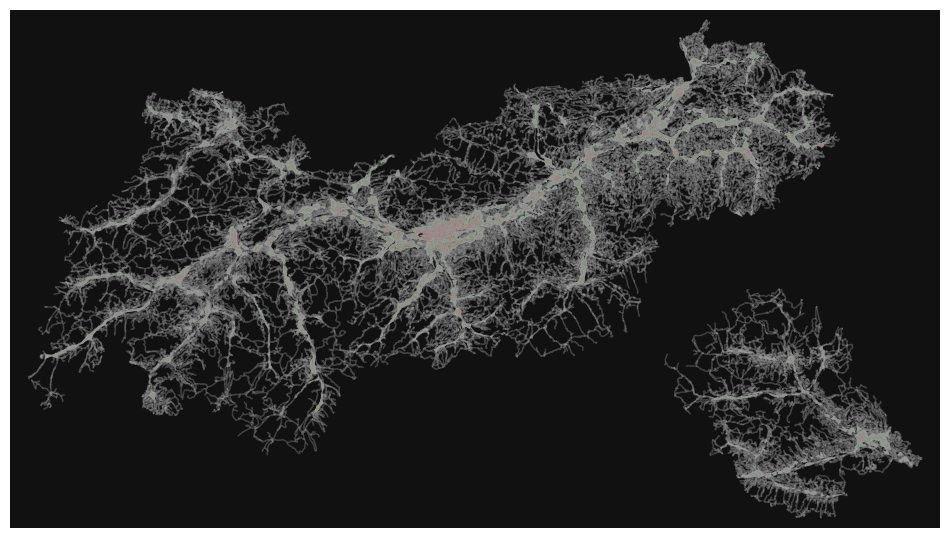

In [43]:
#print(gdf.head())

gdf_dissolved = gdf.dissolve(by="color").reindex(ptsql_colors[::-1])

#print(gdf_dissolved)

draw_graph(G, gdf=gdf_dissolved)

In [ ]:
#gdf_dissolved.to_file(f"{data_path}/dissolved_{place.split(',')[0]}.gpkg", driver="GPKG", layer="isochrones")